In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
filepath = r"C:\Users\91992\Desktop\Air_BNB_Project\Airbnb_Open_Data.csv"
df = pd.read_csv(filepath)
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

C:\Users\91992\AppData\Local\Temp\ipykernel_37964\1568541397.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


In [3]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [4]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

# DATA CLEANING

In [5]:
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)

df.dropna(subset=['NAME', 'host name'], inplace=True)

In [6]:
df.isnull().sum()

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

In [7]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

In [10]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.014100e+05,1.014100e+05,101402.000000,101402.000000,101210.000000,101171.000000,101142.000000,101016.000000,101228.000000,101410,101410.000000,101103.000000,101092.000000,100990.000000
mean,2.920959e+07,4.926155e+10,40.728082,-73.949663,2012.486908,625.381008,125.043998,8.113744,27.511854,2018-05-15 21:26:08.721033728,1.163207,3.278558,7.948463,141.164660
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.507574e+07,2.459183e+10,40.688730,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-30 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.922911e+07,4.912069e+10,40.722300,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-23 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.328308e+07,7.399747e+10,40.762750,-73.932340,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.626820e+07,2.853703e+10,0.055850,0.049474,5.765130,331.609111,66.313374,30.378014,49.549258,NaN,1.683708,1.285369,32.328974,135.419199


In [11]:
df.to_csv("Airbnb_Cleaned_Data.csv", index=False)

In [12]:
df.groupby('room type')['price'].mean()

room type
Entire home/apt    625.380929
Hotel room         666.391304
Private room       624.841233
Shared room        634.542505
Name: price, dtype: float64

In [13]:
df.groupby('neighbourhood group')['price'].mean()

neighbourhood group
Bronx            627.634219
Brooklyn         626.477818
Manhattan        622.826365
Queens           629.980824
Staten Island    623.314894
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64

# Question 1: What drives Price?


Price Distribution

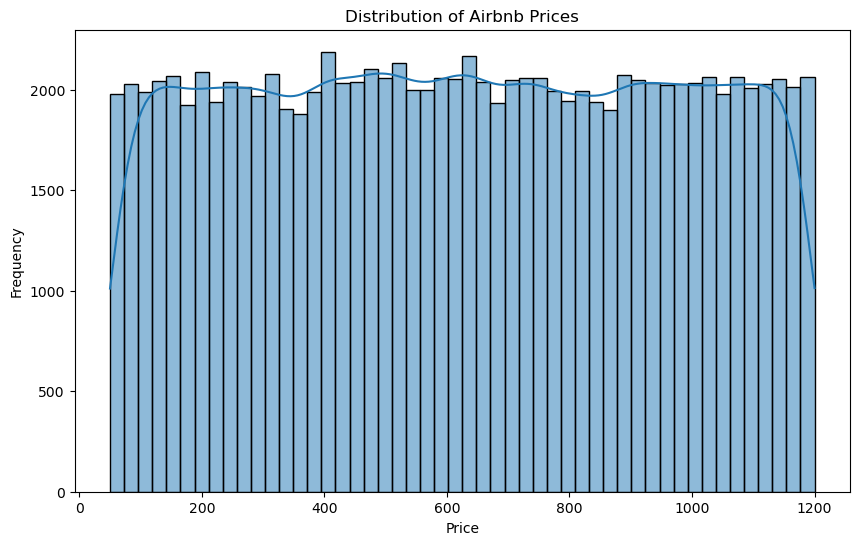

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)

plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

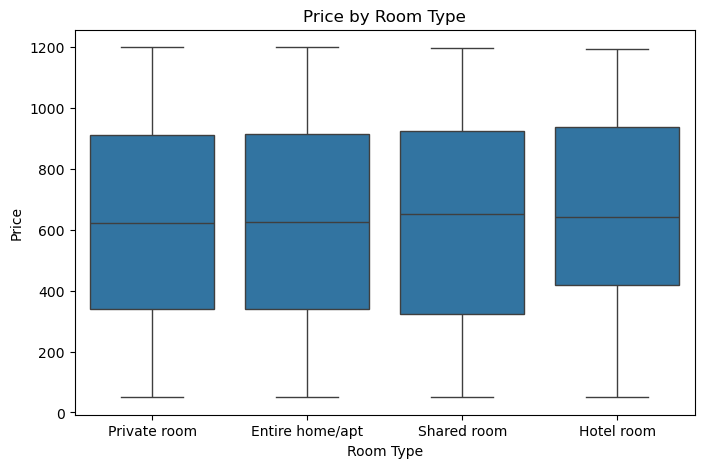

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='room type',
    y='price',
    data=df
)

plt.title('Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price')

plt.show()

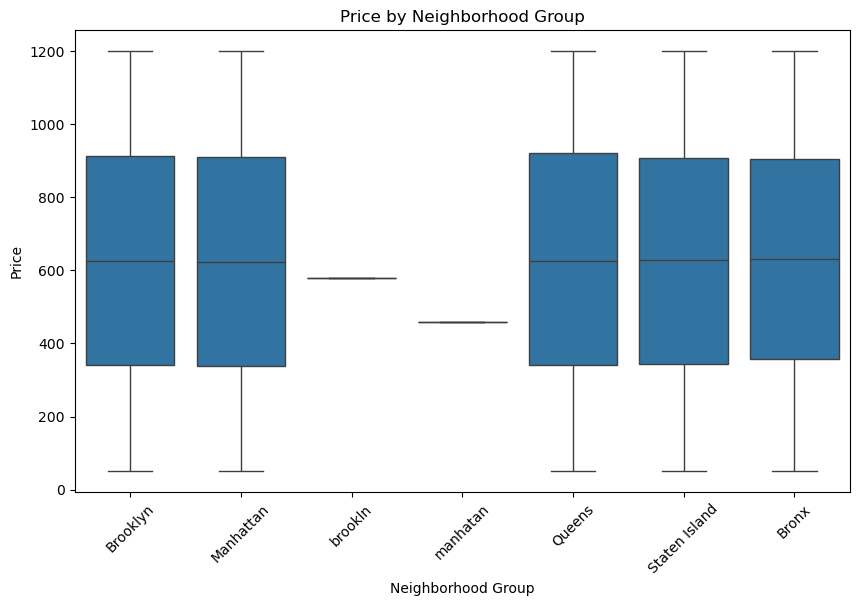

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='neighbourhood group',
    y='price',
    data=df
)

plt.title('Price by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price')

plt.xticks(rotation=45)

plt.show()

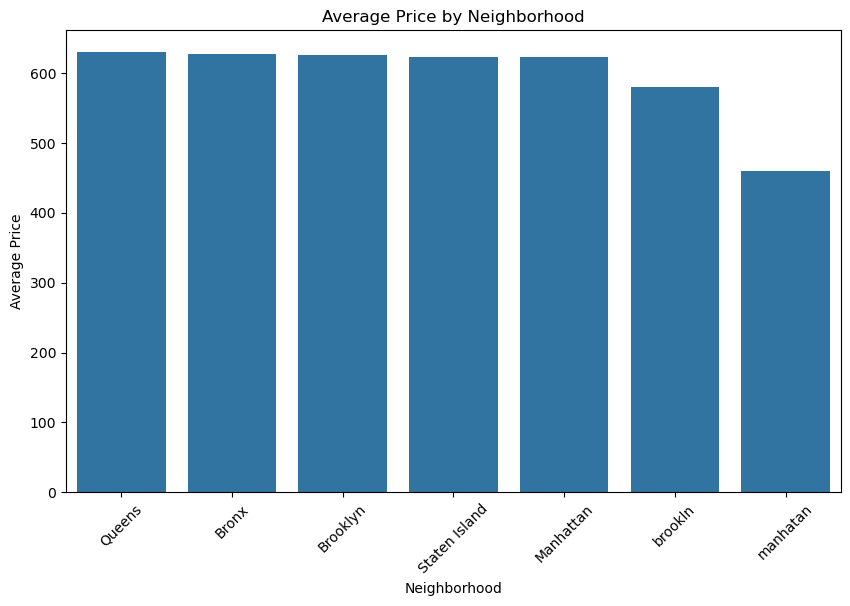

In [17]:
avg_price_area = (
    df.groupby('neighbourhood group')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_price_area.index,
    y=avg_price_area.values
)

plt.title('Average Price by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price')

plt.xticks(rotation=45)

plt.show()

# Question 2:What Drives Availability?

In [18]:
df_avail = df[
    (df['availability 365'] >= 0) &
    (df['availability 365'] <= 365)
]

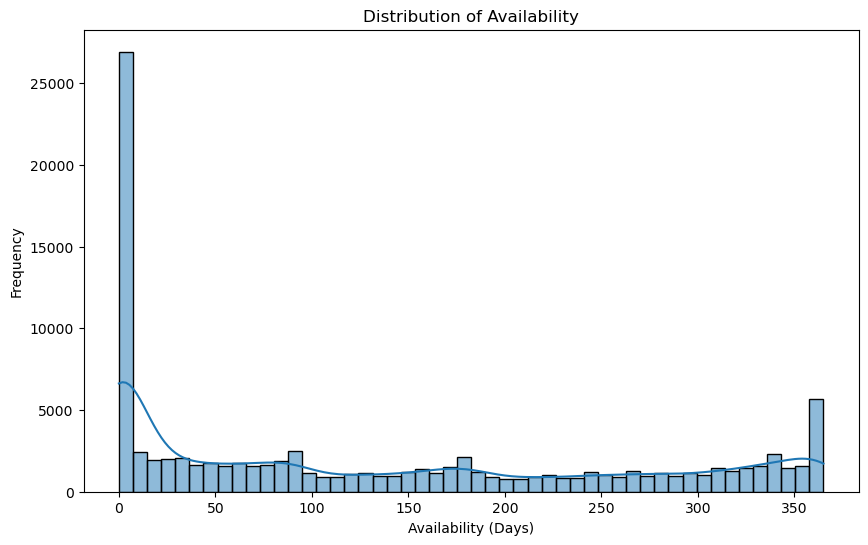

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_avail['availability 365'],
    bins=50,
    kde=True
)

plt.title('Distribution of Availability')
plt.xlabel('Availability (Days)')
plt.ylabel('Frequency')

plt.show()

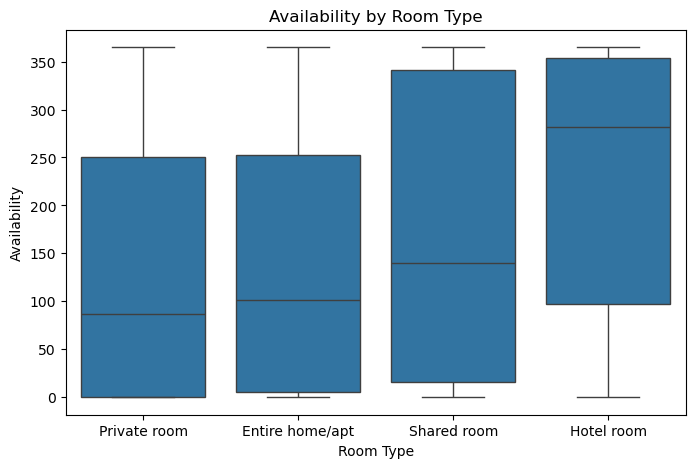

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='room type',
    y='availability 365',
    data=df_avail
)

plt.title('Availability by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Availability')

plt.show()

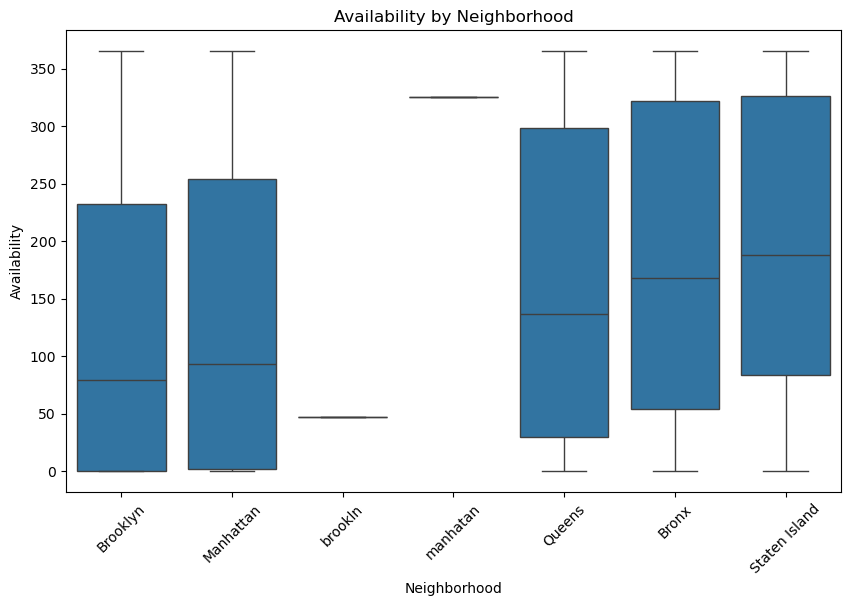

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='neighbourhood group',
    y='availability 365',
    data=df_avail
)

plt.title('Availability by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Availability')

plt.xticks(rotation=45)

plt.show()

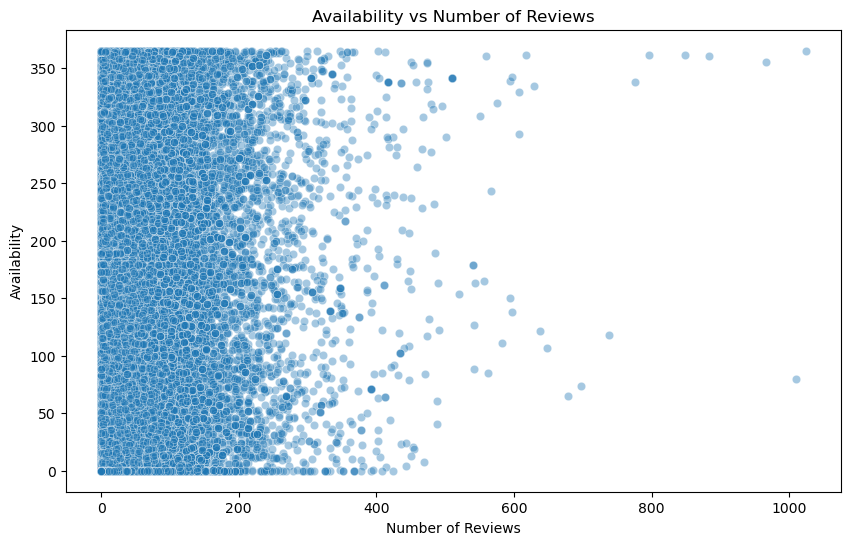

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='number of reviews',
    y='availability 365',
    data=df_avail,
    alpha=0.4
)

plt.title('Availability vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Availability')

plt.show()

# Question 3: What Drives Guest Satisfaction?

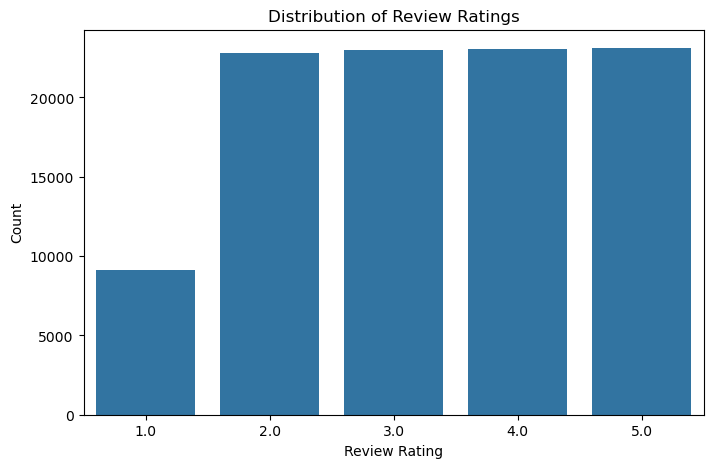

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='review rate number',
    data=df
)

plt.title('Distribution of Review Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Count')

plt.show()

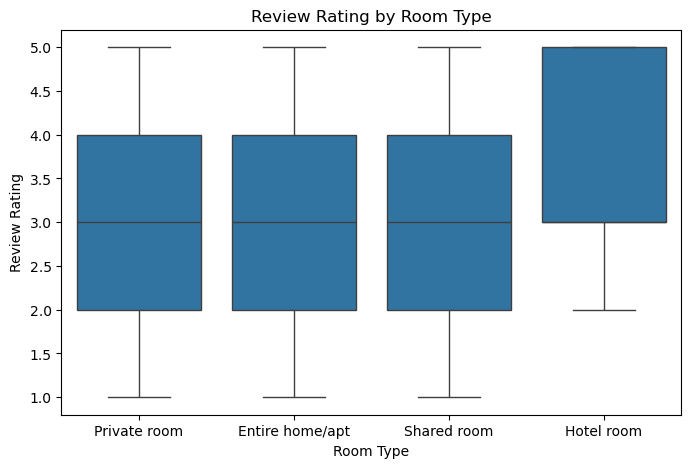

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='room type',
    y='review rate number',
    data=df
)

plt.title('Review Rating by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Review Rating')

plt.show()

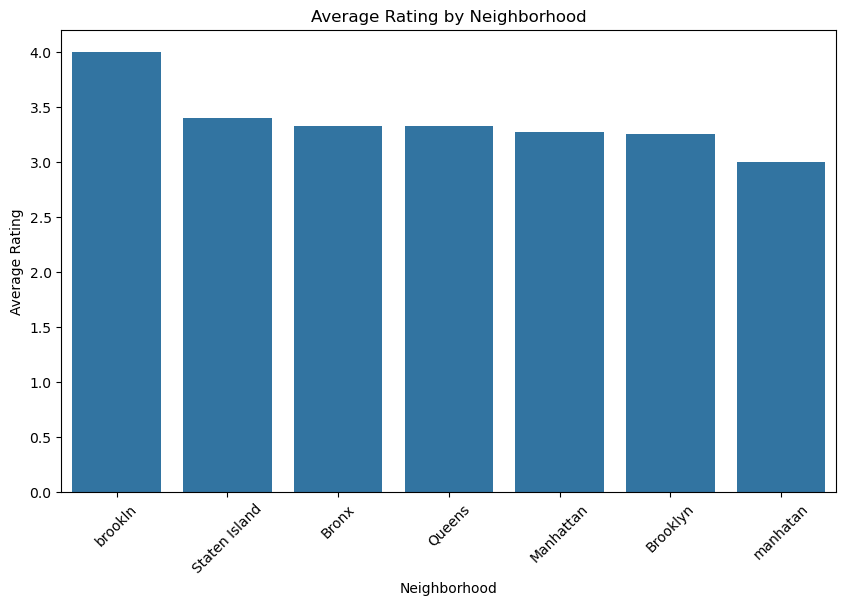

In [25]:
avg_rating = (
    df.groupby('neighbourhood group')['review rate number']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values
)

plt.title('Average Rating by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Rating')

plt.xticks(rotation=45)

plt.show()

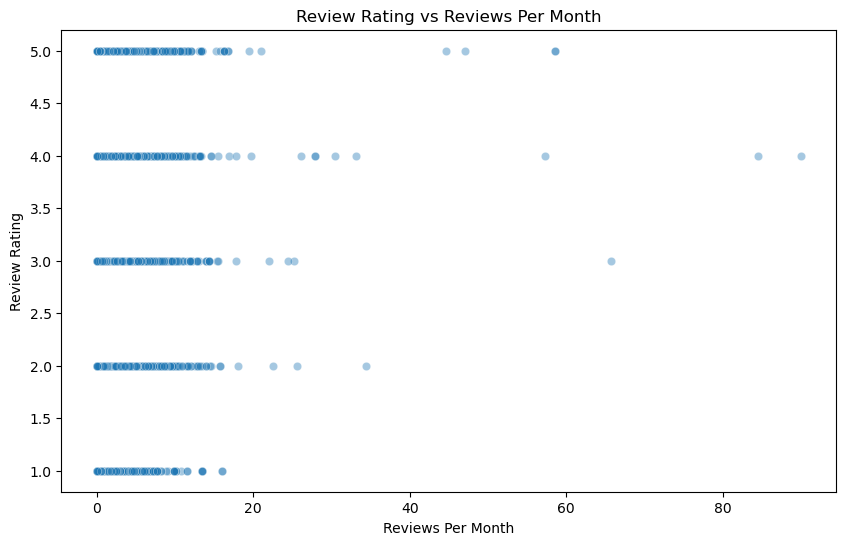

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='reviews per month',
    y='review rate number',
    data=df,
    alpha=0.4
)

plt.title('Review Rating vs Reviews Per Month')
plt.xlabel('Reviews Per Month')
plt.ylabel('Review Rating')

plt.show()

C:\Users\91992\AppData\Local\Temp\ipykernel_37964\2948521180.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_avail['price_category'] = pd.qcut(


<Axes: xlabel='price_category', ylabel='availability 365'>

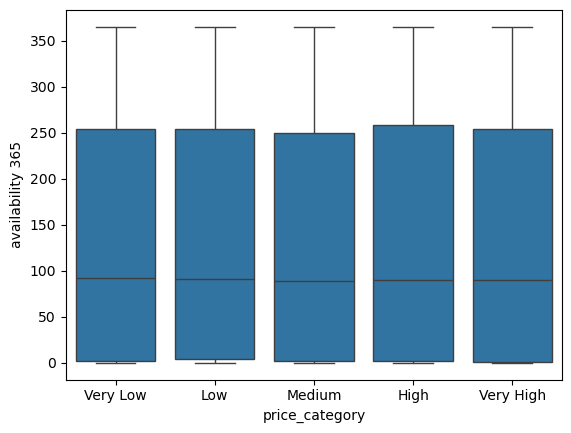

In [27]:
df_avail['price_category'] = pd.qcut(
    df_avail['price'],
    q=5,
    labels=['Very Low','Low','Medium','High','Very High']
)

sns.boxplot(
    x='price_category',
    y='availability 365',
    data=df_avail
)

In [28]:
df_avail[['price','availability 365']].corr()

,price,availability 365
price,1.000000,-0.001998
availability 365,-0.001998,1.000000


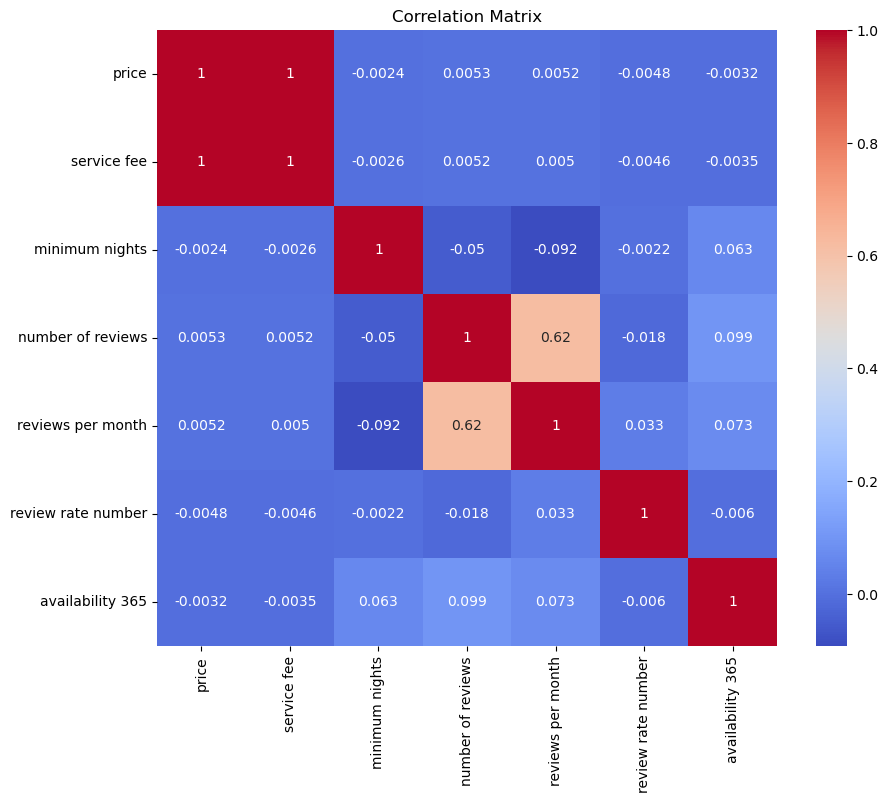

In [29]:
plt.figure(figsize=(10,8))

corr_cols = [
    'price',
    'service fee',
    'minimum nights',
    'number of reviews',
    'reviews per month',
    'review rate number',
    'availability 365'
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()